# ☕ Starbucks Rewards — 세그먼트 타겟팅 한계 분석 및 리워드 비용 구조 개선 프레임워크
### 마케팅-오퍼 전략 제안서 | Team 6조 | 2026.01.21

---
## 📋 목차
| # | 섹션 |
|---|------|
| 1 | 라이브러리 & 데이터 로드 |
| 2 | 기본 EDA — 데이터 구조 탐색 & 신규 가입자 트렌드 |
| 3 | 마스터 테이블 구축 (전처리 + 범주화) |
| 4 | Phase 1 — 세그먼트별 오퍼 반응 분석 |
| 5 | Phase 1 — 머신러닝 기반 오퍼 추천/비추천 예측 |
| 6 | Phase 2 — 루틴형 고객 식별 & 비용 절감 시뮬레이션 |
| 7 | Phase 3 — 우연완료(Incidental Completion) 분석 & 전략 매트릭스 |


---
## 1. 라이브러리 & 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import ast
import warnings
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, classification_report
from scipy import stats

warnings.filterwarnings('ignore')

# ── 한글 폰트 ──────────────────────────────────────────────────────────
import platform, matplotlib
if platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rc('axes', unicode_minus=False)

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

C_GREEN  = '#1B5E45'
C_GOLD   = '#B8860B'
C_RED    = '#C0392B'
C_TEAL   = '#52B788'
C_ORANGE = '#E07B39'

In [2]:
# ── 데이터 로드 ────────────────────────────────────────────────────────

df_portfolio  = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/starbucks project 3/스타벅스 데이터/portfolio.csv', low_memory=False)
df_profile    = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/starbucks project 3/스타벅스 데이터/profile.csv', low_memory=False)
df_transcript = pd.read_csv('/Users/joshuakim/Desktop/스파르타 포트폴리오/starbucks project 3/스타벅스 데이터/transcript.csv', low_memory=False)

for df in [df_portfolio, df_profile, df_transcript]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"portfolio  : {df_portfolio.shape[0]:>6,} rows x {df_portfolio.shape[1]} cols")
print(f"profile    : {df_profile.shape[0]:>6,} rows x {df_profile.shape[1]} cols")
print(f"transcript : {df_transcript.shape[0]:>6,} rows x {df_transcript.shape[1]} cols")

portfolio  :     10 rows x 6 cols
profile    : 17,000 rows x 5 cols
transcript : 306,534 rows x 4 cols


---
## 2. 기본 EDA

### 2-1. 각 테이블 기본 확인

In [33]:
print("[portfolio] 오퍼 메타 정보")
display(df_portfolio)

[portfolio] 오퍼 메타 정보


,reward,channels,difficulty,duration,offer_type,id,n_channels
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,3
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,4
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed,3
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,3
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,2
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,4
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,4
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837,3
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,4
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5,3


In [4]:
print("[profile] 고객 인구통계")
print(df_profile.info())
display(df_profile.head())
print("\n결측치:\n", df_profile.isnull().sum())

[profile] 고객 인구통계
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB
None


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN



결측치:
 gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64


In [5]:
print("[transcript] 거래 이벤트 로그")
print(df_transcript.info())
display(df_transcript.head())
print("\nevent 유형:\n", df_transcript['event'].value_counts())

[transcript] 거래 이벤트 로그
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  object
 1   event   306534 non-null  object
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.4+ MB
None


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0



event 유형:
 event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64


### 2-2. value 컬럼 파싱

In [6]:
def parse_value(v):
    try:    return ast.literal_eval(v)
    except: return {}

df_transcript['value_parsed'] = df_transcript['value'].apply(parse_value)

def get_offer_id(row):
    v = row['value_parsed']
    return v.get('offer id', v.get('offer_id', None))

df_transcript['offer_id_parsed'] = df_transcript.apply(get_offer_id, axis=1)
df_transcript['amount']          = df_transcript['value_parsed'].apply(lambda v: v.get('amount', np.nan))

print("파싱 완료")
display(df_transcript[['event','offer_id_parsed','amount']].head(8))

파싱 완료


,event,offer_id_parsed,amount
0,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,offer received,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,offer received,2906b810c7d4411798c6938adc9daaa5,NaN
3,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,offer received,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN
5,offer received,f19421c1d4aa40978ebb69ca19b0e20d,NaN
6,offer received,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
7,offer received,3f207df678b143eea3cee63160fa8bed,NaN


### 2-3. 2018 신규 가입자 급증

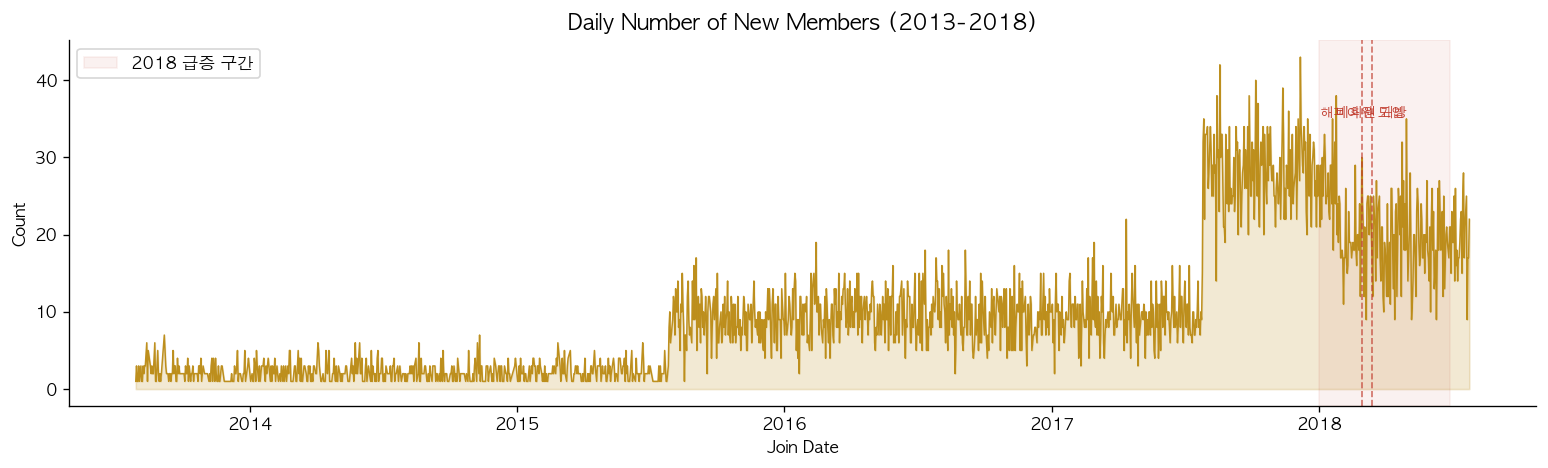

In [7]:
df_profile['join_date'] = pd.to_datetime(df_profile['became_member_on'].astype(str), format='%Y%m%d')

daily_members = (
    df_profile[df_profile['join_date'].notna()]
    .groupby('join_date').size().reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_members['join_date'], daily_members['count'], color=C_GOLD, linewidth=0.9, alpha=0.9)
ax.fill_between(daily_members['join_date'], daily_members['count'], color=C_GOLD, alpha=0.18)
ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2018-06-30'),
           color=C_RED, alpha=0.07, label='2018 급증 구간')

for date_str, label in [('2018-03-01','해피아워 도입'), ('2018-03-15','비회원 개방')]:
    ax.axvline(pd.Timestamp(date_str), color=C_RED, linestyle='--', linewidth=1, alpha=0.7)
    ax.text(pd.Timestamp(date_str), daily_members['count'].max()*0.82,
            label, fontsize=8, color=C_RED, ha='center')

ax.set_title('Daily Number of New Members (2013-2018)', fontsize=13, fontweight='bold')
ax.set_xlabel('Join Date'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()

### 2-4. 오퍼 퍼널 분석 (Receive → View → Complete)

In [8]:
event_counts = df_transcript['event'].value_counts()
received  = event_counts.get('offer received',  0)
viewed    = event_counts.get('offer viewed',     0)
completed = event_counts.get('offer completed',  0)

# 오퍼별 유형 매핑
df_port_lookup = df_portfolio.set_index('id')['offer_type'].to_dict()

# 오퍼 타입별 전환율
df_tr_offer = df_transcript[df_transcript['event'].isin(
    ['offer received','offer viewed','offer completed'])].copy()
df_tr_offer['offer_type'] = df_tr_offer['offer_id_parsed'].map(df_port_lookup)

for otype in ['bogo','discount','informational']:
    sub = df_tr_offer[df_tr_offer['offer_type']==otype]
    r = sub[sub['event']=='offer received']['person'].nunique()
    v = sub[sub['event']=='offer viewed']['person'].nunique()
    c = sub[sub['event']=='offer completed']['person'].nunique()
    print(f"[{otype.upper():<14}] Received:{r:>5,}  Viewed:{v:>5,}  Completed:{c:>5,}  View->Complete:{c/v:.1%}")

print(f"\n전체 퍼널: Received {received:,} -> Viewed {viewed:,} ({viewed/received:.1%}) -> Completed {completed:,} ({completed/received:.1%})")

# 미확인 완료 비율
viewed_ids    = set(df_transcript[df_transcript['event']=='offer viewed']['person'])
df_comp_check = df_transcript[df_transcript['event']=='offer completed'].copy()
df_comp_check['no_view'] = ~df_comp_check['person'].isin(viewed_ids)
no_view_rate  = df_comp_check['no_view'].mean()
print(f"오퍼 미확인 완료 비율: {no_view_rate:.1%} <- 마케팅 효과 없음")

[BOGO          ] Received:14,992  Viewed:14,008  Completed:9,263  View->Complete:66.1%
[DISCOUNT      ] Received:14,945  Viewed:12,676  Completed:10,289  View->Complete:81.2%
[INFORMATIONAL ] Received:10,547  Viewed:8,251  Completed:    0  View->Complete:0.0%

전체 퍼널: Received 76,277 -> Viewed 57,725 (75.7%) -> Completed 33,579 (44.0%)
오퍼 미확인 완료 비율: 0.3% <- 마케팅 효과 없음


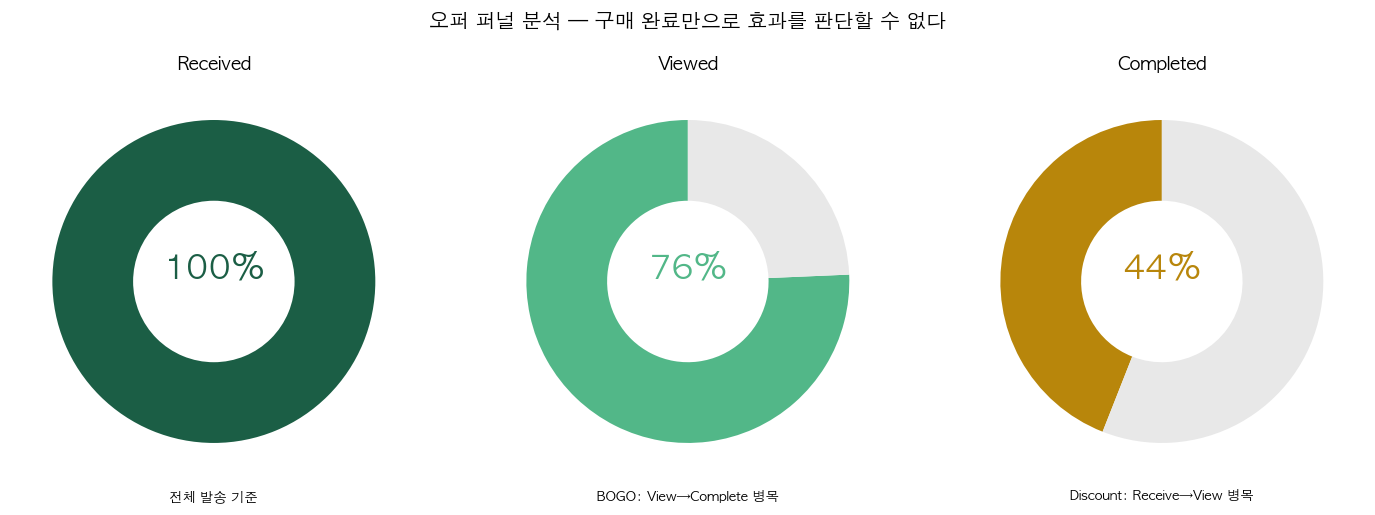

In [9]:
# 퍼널 도넛 차트
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
stages = ['Received', 'Viewed', 'Completed']
vals   = [received, viewed, completed]
labels_sub = ['전체 발송 기준', 'BOGO: View→Complete 병목', 'Discount: Receive→View 병목']
colors = [C_GREEN, C_TEAL, C_GOLD]

for ax, stage, val, color, sub_label in zip(axes, stages, vals, colors, labels_sub):
    pct = val / received * 100
    ax.pie([pct, 100-pct], startangle=90, colors=[color,'#E8E8E8'],
           wedgeprops=dict(width=0.5))
    ax.text(0, 0.08, f"{pct:.0f}%", ha='center', va='center',
            fontsize=20, fontweight='bold', color=color)
    ax.set_title(f"{stage}", fontsize=11, fontweight='bold')
    ax.set_xlabel(sub_label, fontsize=8)

fig.suptitle('오퍼 퍼널 분석 — 구매 완료만으로 효과를 판단할 수 없다',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 3. 마스터 테이블 구축

### 3-1. 고객 특성 범주화

In [10]:
# ① 성별
df_profile['gender_clean'] = df_profile['gender'].fillna('Unknown')

# ② 연령 (SNS 사용률 리서치 기반)
def age_group(age):
    if   age <= 24:  return '24세이하'
    elif age <= 34:  return '25-34세'
    elif age <= 44:  return '35-44세'
    elif age <= 54:  return '45-54세'
    elif age <= 64:  return '55-64세'
    else:            return '65세이상'
df_profile['age_group'] = df_profile['age'].apply(age_group)

# ③ 소득 (2018 미국 가계 인구통계 기준)
def income_group(inc):
    if   pd.isna(inc):   return 'Unknown'
    elif inc < 50000:    return 'Low-End'
    elif inc < 65000:    return 'Mid-Low'
    elif inc < 80000:    return 'Mid-High'
    elif inc < 100000:   return 'High'
    else:                return 'VIP'
df_profile['income_group'] = df_profile['income'].apply(income_group)

# ④ 가입기간 (고객 라이프사이클 리서치 기반)
REF_DATE = pd.Timestamp('2018-08-01')
df_profile['join_date']     = pd.to_datetime(df_profile['became_member_on'].astype(str), format='%Y%m%d')
df_profile['tenure_years']  = (REF_DATE - df_profile['join_date']).dt.days / 365

def tenure_group(y):
    if   y < 1:  return '1년미만'
    elif y <= 3: return '1~3년'
    else:        return '3년이상'
df_profile['tenure_group'] = df_profile['tenure_years'].apply(tenure_group)

print("범주화 완료")
for col in ['gender_clean','age_group','income_group','tenure_group']:
    print(f"  {col}: {df_profile[col].value_counts().to_dict()}")

범주화 완료
  gender_clean: {'M': 8484, 'F': 6129, 'Unknown': 2175, 'O': 212}
  age_group: {'65세이상': 6441, '55-64세': 3421, '45-54세': 3013, '35-44세': 1869, '25-34세': 1380, '24세이하': 876}
  income_group: {'Mid-Low': 3863, 'Low-End': 3781, 'Mid-High': 3464, 'High': 2624, 'Unknown': 2175, 'VIP': 1093}
  tenure_group: {'1년미만': 8503, '1~3년': 7073, '3년이상': 1424}


### 3-2. 마스터 테이블 Join & 이상치 처리

In [11]:
# ① transcript + profile
df_master = df_transcript.merge(
    df_profile[['id','gender_clean','age','age_group','income','income_group',
                'tenure_years','tenure_group','join_date']],
    left_on='person', right_on='id', how='left'
).drop(columns=['id'])

# ② portfolio 병합
df_master = df_master.merge(
    df_portfolio[['id','offer_type','reward','difficulty','duration','channels']],
    left_on='offer_id_parsed', right_on='id', how='left'
).drop(columns=['id'])

# ③ Unknown 제거
mask_unknown = (df_master['gender_clean']=='Unknown') | (df_master['income_group']=='Unknown')
before = len(df_master)
df_master = df_master[~mask_unknown].copy()
print(f"Unknown 제거: {before:,} -> {len(df_master):,}")

# ④ 이상치 처리: amount
df_tx_tmp = df_master[df_master['event']=='transaction']['amount']
df_master  = df_master[~((df_master['event']=='transaction') & (df_master['amount']>=1000))]

tx_a = df_master[df_master['event']=='transaction']['amount']
Q1, Q3 = tx_a.quantile(0.25), tx_a.quantile(0.75)
upper_fence = Q3 + 1.5*(Q3-Q1)
df_master = df_master[~((df_master['event']=='transaction') & (df_master['amount']>upper_fence))].copy()

after = len(df_master)
print(f"이상치 제거 후: {after:,}  (보존율: {after/before:.1%})")
print(f"거래금액 범위: ${tx_a[tx_a<=upper_fence].min():.2f} ~ ${tx_a[tx_a<=upper_fence].max():.2f}")
print(f"마스터 shape: {df_master.shape}")
display(df_master.head(3))

Unknown 제거: 306,534 -> 272,762
이상치 제거 후: 271,761  (보존율: 88.7%)
거래금액 범위: $0.05 ~ $42.33
마스터 shape: (271761, 20)


,person,event,value,time,value_parsed,offer_id_parsed,amount,gender_clean,age,age_group,income,income_group,tenure_years,tenure_group,join_date,offer_type,reward,difficulty,duration,channels
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,F,75,65세이상,100000.0,VIP,1.230137,1~3년,2017-05-09,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']"
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},2906b810c7d4411798c6938adc9daaa5,NaN,M,68,65세이상,70000.0,Mid-High,0.265753,1년미만,2018-04-26,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']"
5,389bc3fa690240e798340f5a15918d5c,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},0,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},f19421c1d4aa40978ebb69ca19b0e20d,NaN,M,65,65세이상,53000.0,Mid-Low,0.473973,1년미만,2018-02-09,bogo,5.0,5.0,5.0,"['web', 'email', 'mobile', 'social']"


### 3-3. 고객별 파생지표 계산

In [12]:
df_tx_clean = df_master[df_master['event']=='transaction'].copy()

# 기본 집계
customer_stats = (
    df_tx_clean.groupby('person')
    .agg(
        total_amount   = ('amount','sum'),
        avg_ticket     = ('amount','mean'),
        tx_count       = ('amount','count'),
        tx_active_days = ('time','nunique'),
    ).reset_index()
)

# 평균 방문 간격 (시간 -> 일)
def avg_gap(times):
    t = sorted(times)
    if len(t) < 2: return np.nan
    return np.mean([(t[i+1]-t[i]) for i in range(len(t)-1)]) / 24

gap_df = df_tx_clean.groupby('person')['time'].apply(avg_gap).reset_index(name='avg_gap_days')
customer_stats = customer_stats.merge(gap_df, on='person', how='left')

# 오퍼 수신 횟수 & 오퍼당 거래량
offer_cnt = (df_master[df_master['event']=='offer received']
             .groupby('person').size().reset_index(name='offer_recv_cnt'))
customer_stats = customer_stats.merge(offer_cnt, on='person', how='left')
customer_stats['offer_recv_cnt'] = customer_stats['offer_recv_cnt'].fillna(0)
customer_stats['tx_per_offer']   = customer_stats['tx_count'] / customer_stats['offer_recv_cnt'].replace(0,np.nan)

# 리워드 합계 & 비율
reward_df = (df_master[df_master['event']=='offer completed']
             .groupby('person')['reward'].sum().reset_index(name='total_reward'))
customer_stats = customer_stats.merge(reward_df, on='person', how='left')
customer_stats['total_reward']  = customer_stats['total_reward'].fillna(0)
customer_stats['reward_ratio']  = customer_stats['total_reward'] / customer_stats['total_amount'].replace(0,np.nan)

# 프로파일 정보
profile_info = (df_master[['person','gender_clean','age','age_group','income',
                            'income_group','tenure_group']].drop_duplicates('person'))
customer_stats = customer_stats.merge(profile_info, on='person', how='left')

print(f"고객 수: {len(customer_stats):,}")
display(customer_stats.head(3))

고객 수: 14,489


,person,total_amount,avg_ticket,tx_count,tx_active_days,avg_gap_days,offer_recv_cnt,tx_per_offer,total_reward,reward_ratio,gender_clean,age,age_group,income,income_group,tenure_group
0,0009655768c64bdeb2e877511632db8f,127.60,15.9500,8,8,2.785714,5.0,1.6,9.0,0.070533,M,33,25-34세,72000.0,Mid-High,1~3년
1,0011e0d4e6b944f998e987f904e8c1e5,79.46,15.8920,5,5,5.437500,5.0,1.0,13.0,0.163604,O,40,35-44세,57000.0,Mid-Low,1년미만
2,0020c2b971eb4e9188eac86d93036a77,196.86,24.6075,8,8,3.892857,5.0,1.6,14.0,0.071117,F,59,55-64세,90000.0,High,1~3년


---
## 4. Phase 1 — 세그먼트별 오퍼 반응 분석
### 가설: 고객 세그먼트별로 최적의 오퍼 타입이 존재한다

### 4-1. 퍼널 데이터프레임 구축

In [13]:
df_recv = df_master[df_master['event']=='offer received'][['person','offer_id_parsed','time']].copy()
df_view = df_master[df_master['event']=='offer viewed'][['person','offer_id_parsed']].copy()
df_comp = df_master[df_master['event']=='offer completed'][['person','offer_id_parsed']].copy()
df_view['viewed'] = True; df_comp['completed'] = True

df_funnel = (df_recv
             .merge(df_view, on=['person','offer_id_parsed'], how='left')
             .merge(df_comp, on=['person','offer_id_parsed'], how='left'))
df_funnel['viewed']    = df_funnel['viewed'].fillna(False)
df_funnel['completed'] = df_funnel['completed'].fillna(False)
df_funnel['responded'] = df_funnel['viewed'] & df_funnel['completed']

# 프로파일 + 포트폴리오 붙이기
df_funnel = df_funnel.merge(
    df_master[['person','income_group','age_group','gender_clean','tenure_group']].drop_duplicates('person'),
    on='person', how='left'
).merge(
    df_portfolio[['id','offer_type','reward','difficulty']].rename(columns={'id':'offer_id_parsed'}),
    on='offer_id_parsed', how='left'
)
print("퍼널 shape:", df_funnel.shape)
display(df_funnel.head(3))

퍼널 shape: (102693, 13)


,person,offer_id_parsed,time,viewed,completed,responded,income_group,age_group,gender_clean,tenure_group,offer_type,reward,difficulty
0,78afa995795e4d85b5d9ceeca43f5fef,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,True,True,True,VIP,65세이상,F,1~3년,bogo,5,5
1,e2127556f4f64592b11af22de27a7932,2906b810c7d4411798c6938adc9daaa5,0,True,False,False,Mid-High,65세이상,M,1년미만,discount,2,10
2,389bc3fa690240e798340f5a15918d5c,f19421c1d4aa40978ebb69ca19b0e20d,0,True,True,True,Mid-Low,65세이상,M,1년미만,bogo,5,5


### 4-2. Profitability Metric — 매출 대비 손실 분석

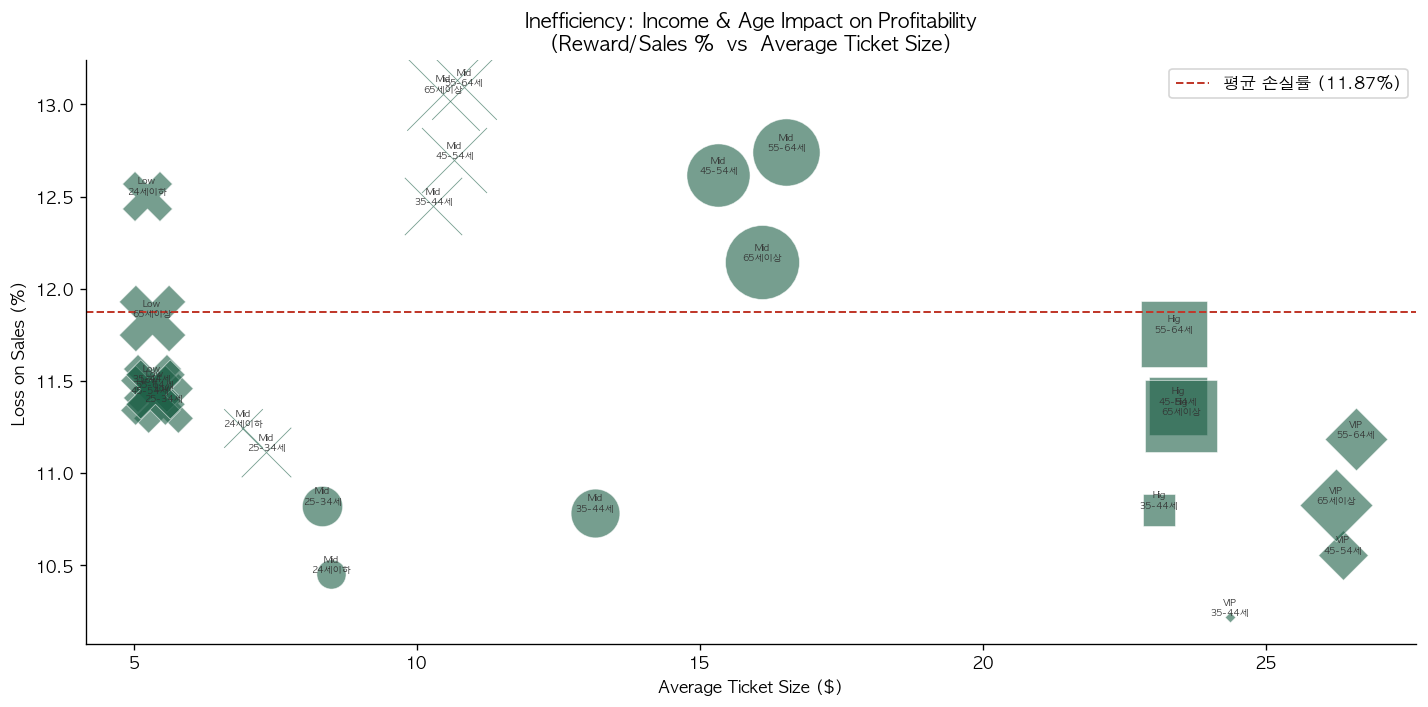

전체 평균 손실률: 11.87%
고소득층: 절대금액 손실 큼 | 저소득층: 상대비율 손실 높음


In [14]:
cs = customer_stats.dropna(subset=['reward_ratio','avg_ticket','income_group']).copy()
cs['profitability_loss'] = cs['reward_ratio'] * 100

seg_prof = (cs.groupby(['income_group','age_group'])
            .agg(avg_loss=('profitability_loss','mean'),
                 avg_ticket=('avg_ticket','mean'),
                 n=('person','count'))
            .reset_index())

avg_loss_global = cs['profitability_loss'].mean()
inc_order = ['Low-End','Mid-Low','Mid-High','High','VIP']
marker_map = {'Low-End':'X','Mid-Low':'x','Mid-High':'o','High':'s','VIP':'D'}

fig, ax = plt.subplots(figsize=(12,6))
for _, row in seg_prof.iterrows():
    ax.scatter(row['avg_ticket'], row['avg_loss'],
               s=max(row['n']*2,20), marker=marker_map.get(row['income_group'],'o'),
               color=C_GREEN, alpha=0.6, edgecolors='white', linewidth=0.5)
    ax.annotate(f"{row['income_group'][:3]}\n{row['age_group']}",
                (row['avg_ticket'], row['avg_loss']),
                fontsize=5.5, ha='center', va='bottom', color='#333')

ax.axhline(avg_loss_global, color=C_RED, linestyle='--', linewidth=1.2,
           label=f'평균 손실률 ({avg_loss_global:.2f}%)')
ax.set_title('Inefficiency: Income & Age Impact on Profitability\n(Reward/Sales %  vs  Average Ticket Size)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Ticket Size ($)'); ax.set_ylabel('Loss on Sales (%)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"전체 평균 손실률: {avg_loss_global:.2f}%")
print("고소득층: 절대금액 손실 큼 | 저소득층: 상대비율 손실 높음")

### 4-3. 전략 매트릭스: 마케팅 반응률 vs 재정 누수율

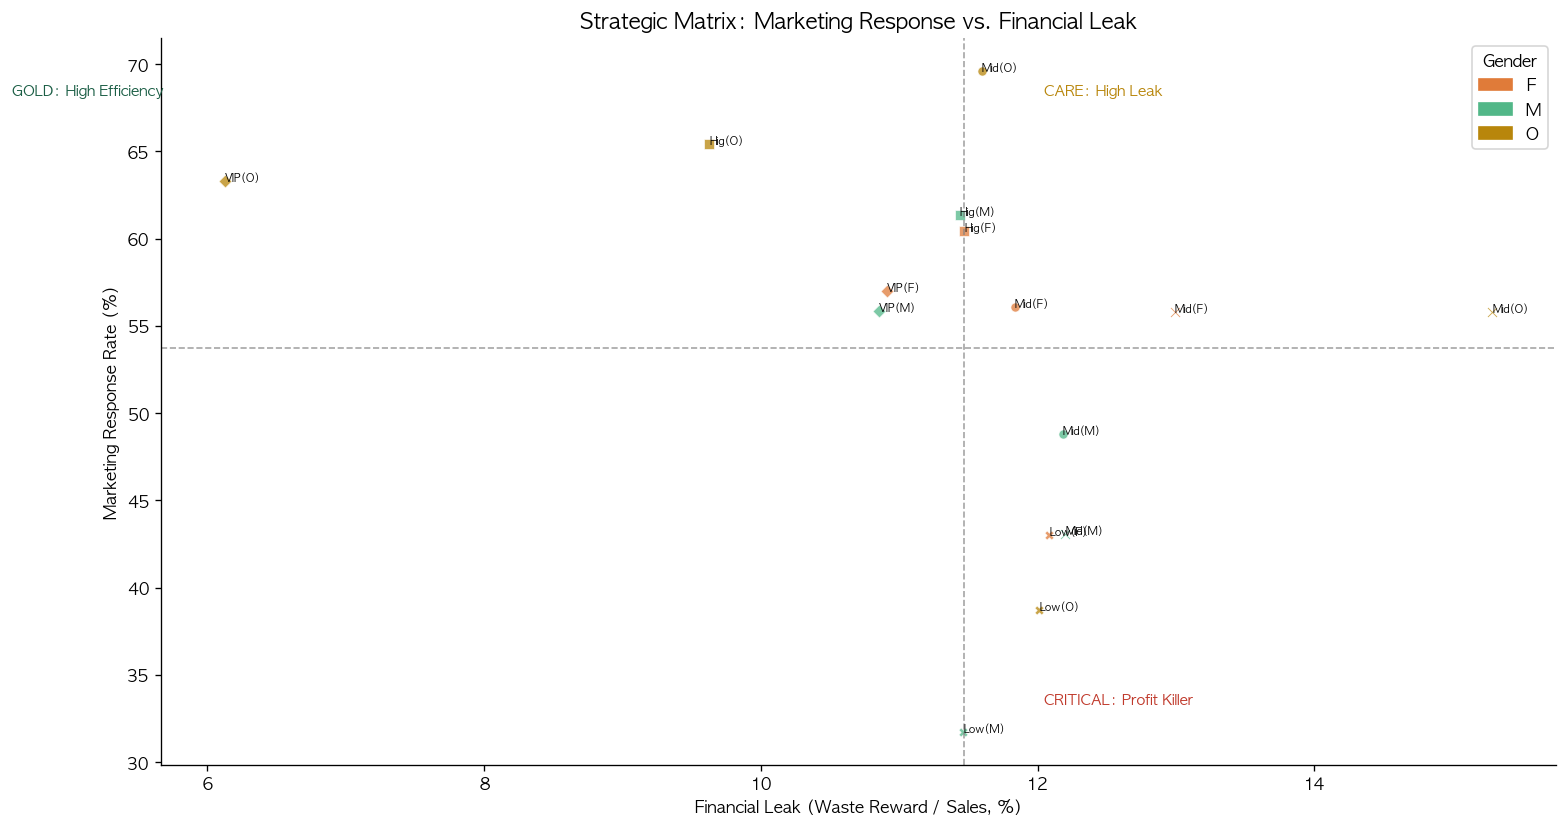

In [15]:
response_by_cust = df_funnel.groupby('person')['responded'].mean().reset_index(name='response_rate')
cs2 = customer_stats.merge(response_by_cust, on='person', how='left')

seg_matrix = (cs2.groupby(['gender_clean','income_group'])
              .agg(mkt_response   =('response_rate','mean'),
                   financial_leak =('reward_ratio','mean'),
                   total_sales    =('total_amount','sum'),
                   n_customers    =('person','count'))
              .reset_index())
seg_matrix['mkt_response']   *= 100
seg_matrix['financial_leak'] *= 100

avg_mkt  = seg_matrix['mkt_response'].mean()
avg_leak = seg_matrix['financial_leak'].mean()

color_map  = {'F':C_ORANGE,'M':C_TEAL,'O':C_GOLD}
marker_map2 = {'Low-End':'X','Mid-Low':'x','Mid-High':'o','High':'s','VIP':'D'}

fig, ax = plt.subplots(figsize=(13,7))
for _, row in seg_matrix.iterrows():
    c = color_map.get(row['gender_clean'],'#999')
    m = marker_map2.get(row['income_group'],'o')
    s = max(np.sqrt(row['total_sales'])*0.05, 30)
    ax.scatter(row['financial_leak'], row['mkt_response'],
               s=s, marker=m, color=c, alpha=0.75, edgecolors='white', linewidth=0.5)
    ax.annotate(f"{row['income_group'][:3]}({row['gender_clean']})",
                (row['financial_leak'], row['mkt_response']), fontsize=6.5)

ax.axhline(avg_mkt,  color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(avg_leak, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.text(avg_leak*0.4, seg_matrix['mkt_response'].max()*0.98,
        'GOLD: High Efficiency', fontsize=9, fontweight='bold', color=C_GREEN)
ax.text(avg_leak*1.05, seg_matrix['mkt_response'].max()*0.98,
        'CARE: High Leak', fontsize=9, fontweight='bold', color=C_GOLD)
ax.text(avg_leak*1.05, seg_matrix['mkt_response'].min()*1.05,
        'CRITICAL: Profit Killer', fontsize=9, fontweight='bold', color=C_RED)

patches = [mpatches.Patch(color=v, label=k) for k,v in color_map.items()]
ax.legend(handles=patches, title='Gender')
ax.set_xlabel('Financial Leak (Waste Reward / Sales, %)')
ax.set_ylabel('Marketing Response Rate (%)')
ax.set_title('Strategic Matrix: Marketing Response vs. Financial Leak', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4-4. 충성 고객 ≠ 수익성 고객

방문일수 vs 객단가  피어슨 r = -0.2293  (p=0.0000)
=> 충성도와 수익성은 별개의 지표


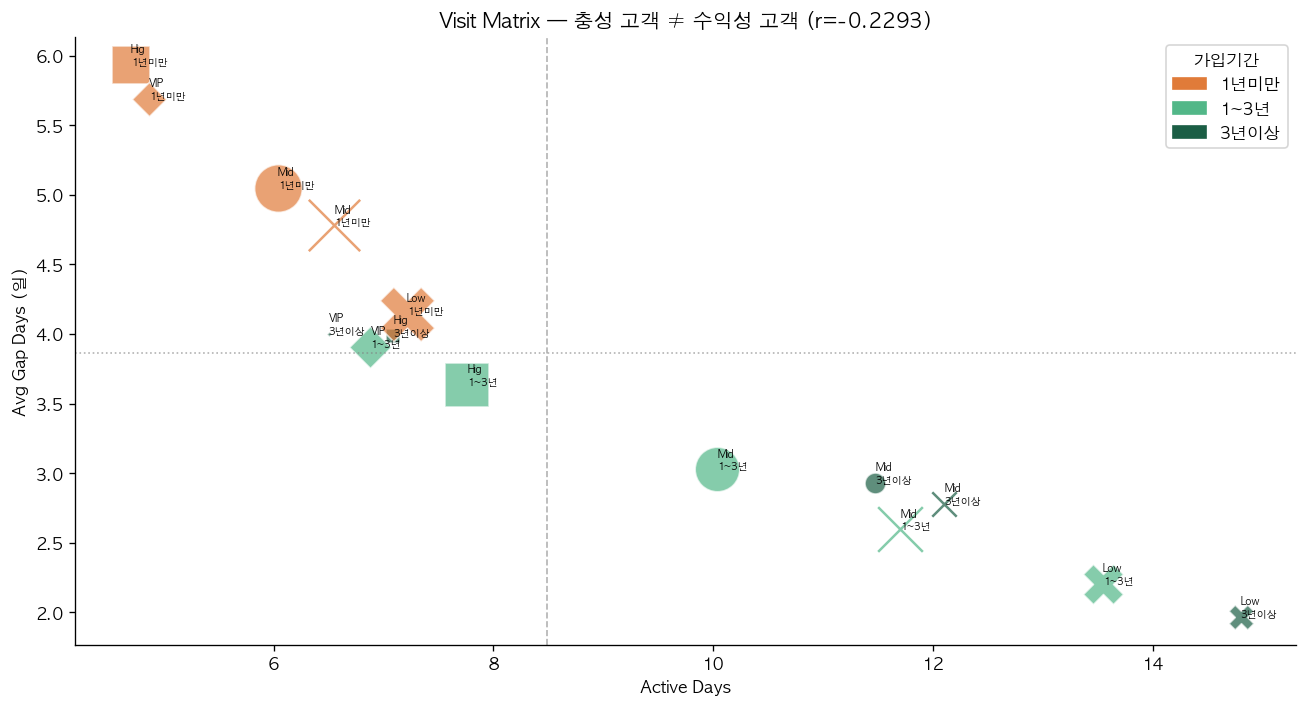

In [16]:
cs_clean = customer_stats.dropna(subset=['tx_active_days','avg_ticket']).copy()
r, p = stats.pearsonr(cs_clean['tx_active_days'], cs_clean['avg_ticket'])
print(f"방문일수 vs 객단가  피어슨 r = {r:.4f}  (p={p:.4f})")
print("=> 충성도와 수익성은 별개의 지표")

color_tenure = {'1년미만':C_ORANGE,'1~3년':C_TEAL,'3년이상':C_GREEN}
marker_inc   = {'Low-End':'X','Mid-Low':'x','Mid-High':'o','High':'s','VIP':'D'}

seg_visit = (cs_clean.groupby(['income_group','tenure_group'])
             .agg(avg_active_days=('tx_active_days','mean'),
                  avg_gap=('avg_gap_days','mean'), n=('person','count'))
             .reset_index().dropna())

fig, ax = plt.subplots(figsize=(11,6))
for _, row in seg_visit.iterrows():
    ax.scatter(row['avg_active_days'], row['avg_gap'],
               s=row['n']*0.5, marker=marker_inc.get(row['income_group'],'o'),
               color=color_tenure.get(row['tenure_group'],'#999'), alpha=0.7, edgecolors='white')
    ax.annotate(f"{row['income_group'][:3]}\n{row['tenure_group']}",
                (row['avg_active_days'], row['avg_gap']), fontsize=6)

ax.axvline(cs_clean['tx_active_days'].mean(), color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(cs_clean['avg_gap_days'].mean(),   color='gray', linestyle=':',  linewidth=1, alpha=0.6)

patches = [mpatches.Patch(color=v, label=k) for k,v in color_tenure.items()]
ax.legend(handles=patches, title='가입기간')
ax.set_xlabel('Active Days'); ax.set_ylabel('Avg Gap Days (일)')
ax.set_title(f'Visit Matrix — 충성 고객 ≠ 수익성 고객 (r={r:.4f})', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### 4-5. 소득 그룹별 리워드 크기별 전환율

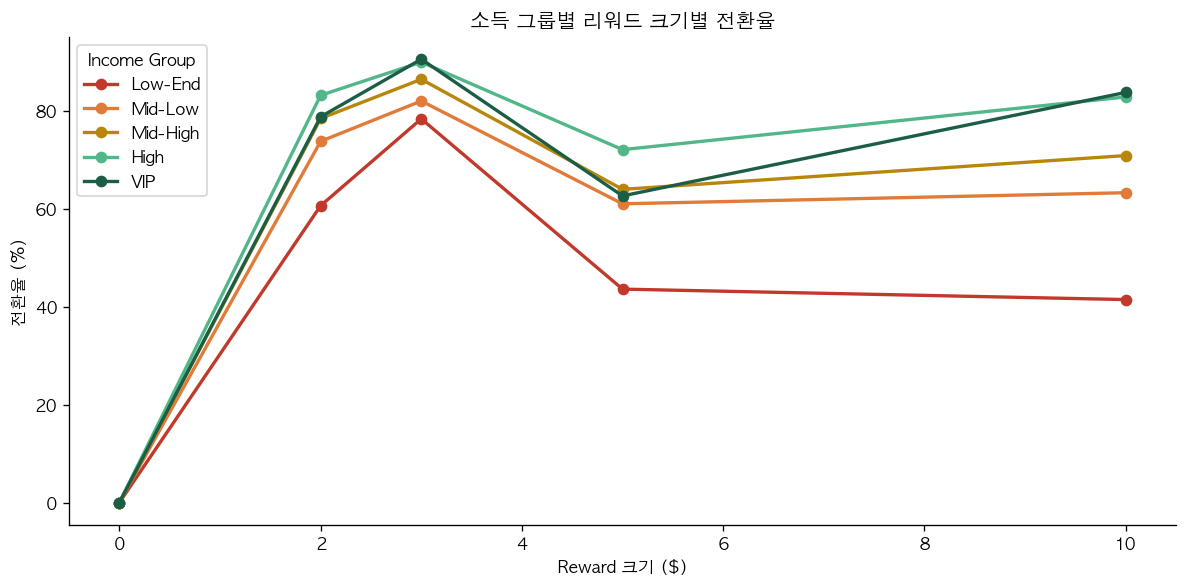

In [17]:
conv_by_reward = (df_funnel.dropna(subset=['income_group','reward'])
                  .groupby(['income_group','reward'])['responded']
                  .mean().reset_index())
conv_by_reward['responded'] *= 100

inc_order = ['Low-End','Mid-Low','Mid-High','High','VIP']
color_inc = dict(zip(inc_order,[C_RED,C_ORANGE,C_GOLD,C_TEAL,C_GREEN]))

fig, ax = plt.subplots(figsize=(10,5))
for inc in inc_order:
    sub = conv_by_reward[conv_by_reward['income_group']==inc].sort_values('reward')
    ax.plot(sub['reward'], sub['responded'], marker='o', label=inc,
            color=color_inc[inc], linewidth=2)
ax.set_xlabel('Reward 크기 ($)'); ax.set_ylabel('전환율 (%)')
ax.set_title('소득 그룹별 리워드 크기별 전환율', fontsize=12, fontweight='bold')
ax.legend(title='Income Group'); plt.tight_layout(); plt.show()

### 4-6. 세그먼트별 반응 차이 검증 (오퍼 유형 × 채널 조합)

In [18]:
# 오퍼 타입별 전환율
pivot = (df_funnel.dropna(subset=['offer_type'])
         .groupby(['income_group','offer_type'])['responded']
         .mean().unstack('offer_type') * 100).round(2)
print("[소득 그룹 × 오퍼 타입별 전환율 (%) — 세그먼트 차이 미미]")
print(pivot.to_string())

# 채널 수 별 전환율
df_portfolio['n_channels'] = df_portfolio['channels'].apply(
    lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
ch_map = df_portfolio.set_index('id')['n_channels'].to_dict()
df_funnel['n_channels'] = df_funnel['offer_id_parsed'].map(ch_map)

ch_conv = (df_funnel.groupby('n_channels')['responded'].mean() * 100).reset_index()
print("\n[채널 수 별 전환율]"); print(ch_conv.to_string(index=False))
print("\n=> 세그먼트별 반응 차이 크지 않음 -> 새로운 기준 필요")

[소득 그룹 × 오퍼 타입별 전환율 (%) — 세그먼트 차이 미미]
offer_type     bogo  discount  informational
income_group                                
High          80.89     79.15            0.0
Low-End       47.39     57.76            0.0
Mid-High      71.72     73.73            0.0
Mid-Low       65.99     69.84            0.0
VIP           79.14     73.14            0.0

[채널 수 별 전환율]
 n_channels  responded
          2  38.168299
          3  40.290284
          4  78.150748

=> 세그먼트별 반응 차이 크지 않음 -> 새로운 기준 필요


---
## 5. Phase 1 — 머신러닝 기반 오퍼 추천/비추천 예측

In [19]:
df_ml = df_funnel.dropna(subset=['income_group','age_group','gender_clean',
                                   'tenure_group','offer_type','responded']).copy()
df_ml['customer_type'] = (df_ml['income_group']+'_'+df_ml['tenure_group']
                          +'_'+df_ml['age_group']+'_'+df_ml['gender_clean'])

le_ct = LabelEncoder(); le_ot = LabelEncoder()
le_in = LabelEncoder(); le_ag = LabelEncoder()
le_gd = LabelEncoder(); le_tg = LabelEncoder()

df_ml['enc_customer_type'] = le_ct.fit_transform(df_ml['customer_type'])
df_ml['enc_offer_type']    = le_ot.fit_transform(df_ml['offer_type'])
df_ml['enc_income']        = le_in.fit_transform(df_ml['income_group'])
df_ml['enc_age']           = le_ag.fit_transform(df_ml['age_group'])
df_ml['enc_gender']        = le_gd.fit_transform(df_ml['gender_clean'])
df_ml['enc_tenure']        = le_tg.fit_transform(df_ml['tenure_group'])

FEATURES = ['enc_customer_type','enc_offer_type','enc_income','enc_age',
            'enc_gender','enc_tenure','reward','difficulty']
X = df_ml[FEATURES]; y = df_ml['responded'].astype(int)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
print(f"Accuracy  : {acc:.2f}")
print(f"Precision : {prec:.2f}")
print(); print(classification_report(y_test, y_pred))

Accuracy  : 0.79
Precision : 0.76

              precision    recall  f1-score   support

           0       0.85      0.60      0.70      8702
           1       0.76      0.92      0.83     11837

    accuracy                           0.79     20539
   macro avg       0.81      0.76      0.77     20539
weighted avg       0.80      0.79      0.78     20539



In [20]:
# 세그먼트별 추천/비추천 오퍼 도출
recommendations = []
for seg in df_ml['customer_type'].unique():
    sub = df_ml[df_ml['customer_type']==seg]
    if len(sub) < 5: continue
    conv = sub.groupby('offer_type')['responded'].mean().sort_values(ascending=False)
    if len(conv) < 2: continue
    best  = conv.idxmax(); worst = conv.idxmin()
    waste = (conv[worst]-conv.max())/conv.max()*-1
    recommendations.append({'customer_type':seg,
                             'recommendation':f"avoid '{worst}' / prefer '{best}'",
                             'best_offer':best,'worst_offer':worst,
                             'waste_reduction_pct':round(waste*100,1),'n':len(sub)})

df_rec = pd.DataFrame(recommendations).sort_values('waste_reduction_pct', ascending=False)
print("[세그먼트별 오퍼 추천/비추천]")
display(df_rec.head(20))
print(f"\n낭비 감소 20%+: {(df_rec['waste_reduction_pct']>=20).sum()}개")
print(f"낭비 감소 10%+: {(df_rec['waste_reduction_pct']>=10).sum()}개")
print(f"낭비 감소  5%+: {(df_rec['waste_reduction_pct']>= 5).sum()}개")

[세그먼트별 오퍼 추천/비추천]


,customer_type,recommendation,best_offer,worst_offer,waste_reduction_pct,n
0,VIP_1~3년_65세이상_F,avoid 'informational' / prefer 'bogo',bogo,informational,100.0,1283
130,Mid-Low_1~3년_25-34세_O,avoid 'informational' / prefer 'discount',discount,informational,100.0,12
121,High_3년이상_55-64세_M,avoid 'informational' / prefer 'discount',discount,informational,100.0,201
122,High_3년이상_65세이상_M,avoid 'informational' / prefer 'discount',discount,informational,100.0,211
123,Mid-Low_1~3년_25-34세_F,avoid 'informational' / prefer 'bogo',bogo,informational,100.0,404
124,VIP_1년미만_45-54세_F,avoid 'informational' / prefer 'bogo',bogo,informational,100.0,413
125,Mid-Low_3년이상_55-64세_M,avoid 'informational' / prefer 'discount',discount,informational,100.0,403
126,Low-End_1~3년_65세이상_F,avoid 'informational' / prefer 'bogo',bogo,informational,100.0,781
127,Low-End_3년이상_35-44세_F,avoid 'informational' / prefer 'bogo',bogo,informational,100.0,95
128,High_1~3년_45-54세_O,avoid 'informational' / prefer 'bogo',bogo,informational,100.0,94



낭비 감소 20%+: 189개
낭비 감소 10%+: 190개
낭비 감소  5%+: 190개


---
## 6. Phase 2 — 루틴형 고객 식별 & 비용 절감 시뮬레이션
### 가설: 우리는 모든 고객에게 오퍼를 보내야 할까?

### 6-1. Routine Score 계산

In [21]:
cs_r = customer_stats.dropna(subset=['tx_active_days','avg_gap_days','tx_per_offer']).copy()

def minmax(s): return (s-s.min())/(s.max()-s.min()+1e-9)

cs_r['norm_active'] = minmax(cs_r['tx_active_days'])
cs_r['norm_gap']    = minmax(-cs_r['avg_gap_days'])     # 짧을수록 좋음
cs_r['norm_tx_per'] = minmax(cs_r['tx_per_offer'])

# Routine Score = 0.45×Active Days + 0.35×(-Avg Gap Days) + 0.20×Tx per Offer
cs_r['routine_score'] = (0.45*cs_r['norm_active']
                        +0.35*cs_r['norm_gap']
                        +0.20*cs_r['norm_tx_per'])

threshold = cs_r['routine_score'].quantile(0.70)   # 상위 30%
cs_r['is_routine'] = cs_r['routine_score'] >= threshold

print(f"전체 고객   : {len(cs_r):>6,}")
print(f"루틴형 고객 : {cs_r['is_routine'].sum():>6,}  ({cs_r['is_routine'].mean():.1%})")
print("\n[루틴형 vs 비루틴형 비교]")
display(cs_r.groupby('is_routine')[['tx_active_days','avg_gap_days','tx_per_offer','avg_ticket','total_reward']].mean().round(2))

전체 고객   : 14,160
루틴형 고객 :  4,260  (30.1%)

[루틴형 vs 비루틴형 비교]


,tx_active_days,avg_gap_days,tx_per_offer,avg_ticket,total_reward
is_routine,,,,,
False,5.98,4.72,1.43,14.49,10.15
True,14.89,1.88,3.40,10.68,13.84


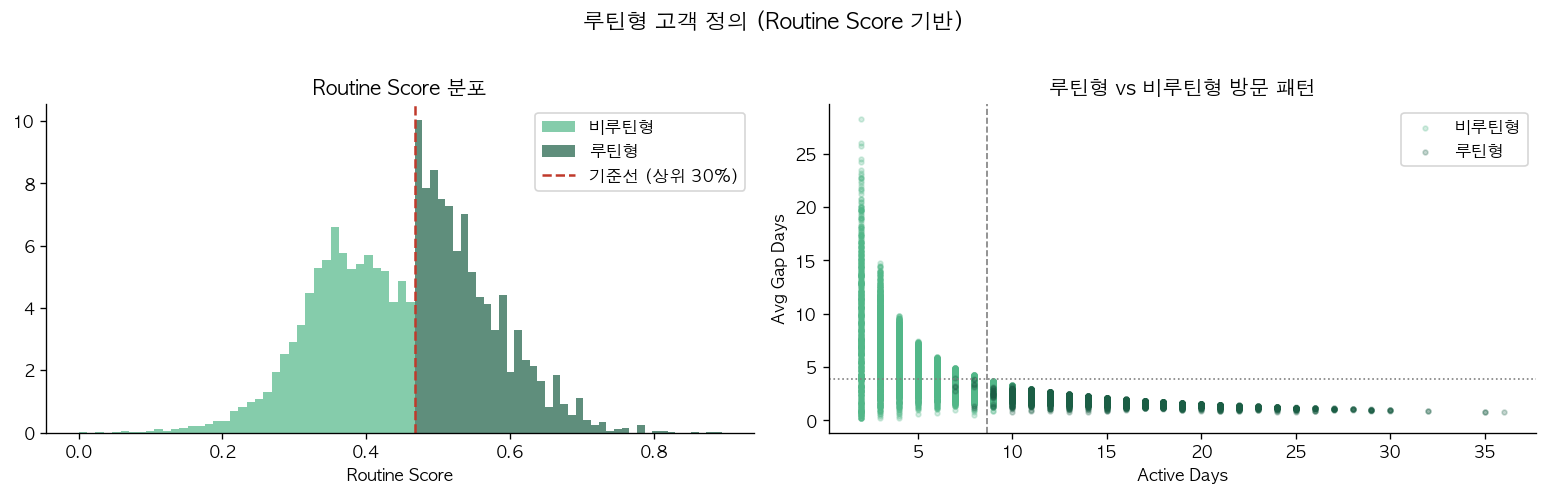

In [22]:
fig, axes = plt.subplots(1,2,figsize=(13,4))

ax = axes[0]
ax.hist(cs_r[~cs_r['is_routine']]['routine_score'], bins=40,
        color=C_TEAL, alpha=0.7, label='비루틴형', density=True)
ax.hist(cs_r[cs_r['is_routine']]['routine_score'], bins=40,
        color=C_GREEN, alpha=0.7, label='루틴형', density=True)
ax.axvline(threshold, color=C_RED, linestyle='--', linewidth=1.5, label='기준선 (상위 30%)')
ax.set_xlabel('Routine Score'); ax.set_title('Routine Score 분포'); ax.legend()

ax = axes[1]
for is_r, grp in cs_r.groupby('is_routine'):
    ax.scatter(grp['tx_active_days'], grp['avg_gap_days'],
               alpha=0.25, s=8, color=C_GREEN if is_r else C_TEAL,
               label='루틴형' if is_r else '비루틴형')
ax.axvline(cs_r['tx_active_days'].mean(), color='gray', linestyle='--', linewidth=1)
ax.axhline(cs_r['avg_gap_days'].mean(),   color='gray', linestyle=':',  linewidth=1)
ax.set_xlabel('Active Days'); ax.set_ylabel('Avg Gap Days')
ax.set_title('루틴형 vs 비루틴형 방문 패턴'); ax.legend()

plt.suptitle('루틴형 고객 정의 (Routine Score 기반)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 6-2. 오퍼 운영 시나리오 & 비용 절감 시뮬레이션

In [24]:
DROP_RATE = {'bogo':0.50, 'discount':0.50, 'informational':0.00}
INCREMENTALITY = {'bogo':0.12, 'discount':0.05, 'informational':0.02}
AVG_REWARD_COST= {'bogo':7.5, 'discount':3.0, 'informational':0}

routine_ids = set(cs_r[cs_r['is_routine']]['person'])

df_recv_r = df_master[
    (df_master['event']=='offer received') &
    (df_master['person'].isin(routine_ids))
].dropna(subset=['offer_type'])

avg_tx_amt = df_master[(df_master['event']=='transaction')
                        & (df_master['person'].isin(routine_ids))]['amount'].mean()

results, loss_results = {}, {}
for otype, drop in DROP_RATE.items():
    sub      = df_recv_r[df_recv_r['offer_type']==otype]
    n_drop   = int(len(sub)*drop)
    reward_s = n_drop * AVG_REWARD_COST[otype]
    exp_loss = n_drop * avg_tx_amt * INCREMENTALITY[otype]
    results[otype]      = {'n_total':len(sub),'n_dropped':n_drop,'reward_saved':reward_s}
    loss_results[otype] = exp_loss

total_saved  = sum(r['reward_saved'] for r in results.values())
total_loss   = sum(loss_results.values())
net_benefit  = total_saved - total_loss

# Expected Loss 공식 출력
print("Expected Loss = Drop Rate x Transaction Amount x Incrementality Rate")
print()
print(f"{'항목':<20}{'절감 비용':>12}{'매출 손실':>12}")
print("-"*46)
for ot in DROP_RATE:
    print(f"  {ot:<18}${results[ot]['reward_saved']:>10,.0f}  ${loss_results[ot]:>10,.0f}")
print("="*46)
print(f"{'합계':<20}${total_saved:>10,.0f}  ${total_loss:>10,.0f}")
print(f"\n  순 기대효과 (Net Benefit): ${net_benefit:,.0f}")

Expected Loss = Drop Rate x Transaction Amount x Incrementality Rate

항목                         절감 비용       매출 손실
----------------------------------------------
  bogo              $    30,052  $     4,845
  discount          $    12,090  $     2,030
  informational     $         0  $         0
합계                  $    42,142  $     6,875

  순 기대효과 (Net Benefit): $35,268


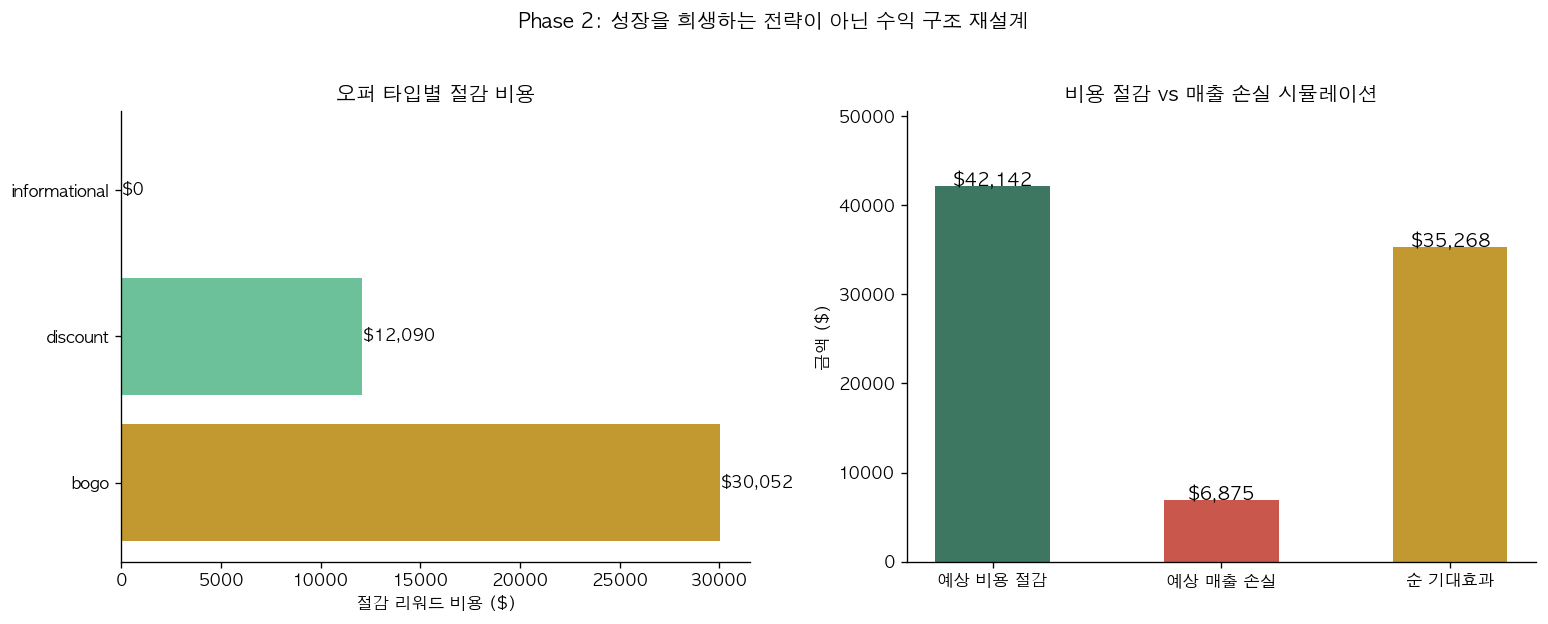

In [25]:
fig, axes = plt.subplots(1,2,figsize=(13,5))

ax = axes[0]
otypes = list(DROP_RATE.keys())
saved_v = [results[o]['reward_saved'] for o in otypes]
bars = ax.barh(otypes, saved_v, color=[C_GOLD,C_TEAL,C_GREEN], alpha=0.85)
for bar,val in zip(bars,saved_v):
    ax.text(val+30, bar.get_y()+bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=10)
ax.set_xlabel('절감 리워드 비용 ($)'); ax.set_title('오퍼 타입별 절감 비용', fontsize=12, fontweight='bold')

ax = axes[1]
labels = ['예상 비용 절감','예상 매출 손실','순 기대효과']
values = [total_saved, total_loss, net_benefit]
bars2 = ax.bar(labels, values, color=[C_GREEN,C_RED,C_GOLD], alpha=0.85, width=0.5)
for bar,val in zip(bars2,values):
    ax.text(bar.get_x()+bar.get_width()/2, val+50, f'${val:,.0f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('금액 ($)'); ax.set_ylim(0, max(values)*1.2)
ax.set_title('비용 절감 vs 매출 손실 시뮬레이션', fontsize=12, fontweight='bold')

plt.suptitle('Phase 2: 성장을 희생하는 전략이 아닌 수익 구조 재설계',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

---
## 7. Phase 3 — 우연완료(Incidental Completion) 분석
### 가설: 어떤 고객에게 오퍼는 행동 변화 없이 단순 비용으로 작용하는가?

### 7-1. 관점의 전환 — 세그먼트 → 마케팅 기여도

In [26]:
# Phase 1 결과 재확인: 오퍼 타입 변경으로 의미있는 차이가 나는 세그먼트 비율
if len(df_rec) > 0:
    meaningful = (df_rec['waste_reduction_pct'] >= 10).mean()
    print(f"오퍼 타입 변경으로 10%+ 차이 세그먼트: {meaningful:.1%}")
    print(f"나머지 {1-meaningful:.1%} 세그먼트: 오퍼 유형 변경해도 성과 차이 미미")
    print()
print("=> '무엇을 주느냐'보다 '오퍼가 실제 행동을 만들었느냐'가 더 중요")
print("=> 마케팅 기여도(Attribution) 자체를 측정해야 함")

오퍼 타입 변경으로 10%+ 차이 세그먼트: 99.0%
나머지 1.0% 세그먼트: 오퍼 유형 변경해도 성과 차이 미미

=> '무엇을 주느냐'보다 '오퍼가 실제 행동을 만들었느냐'가 더 중요
=> 마케팅 기여도(Attribution) 자체를 측정해야 함


### 7-2. 4유형 고객 분류 퍼널 재정의

[오퍼 발송 1회 기준 4유형 분류]
  A_마케팅기여        :  59,208건  (57.7%)
  B_설득가능         :  28,404건  (27.7%)
  D_무반응          :   9,297건  (9.1%)
  C_우연완료         :   5,784건  (5.6%)

▶ 우연완료(C유형) 비중: 5.6%


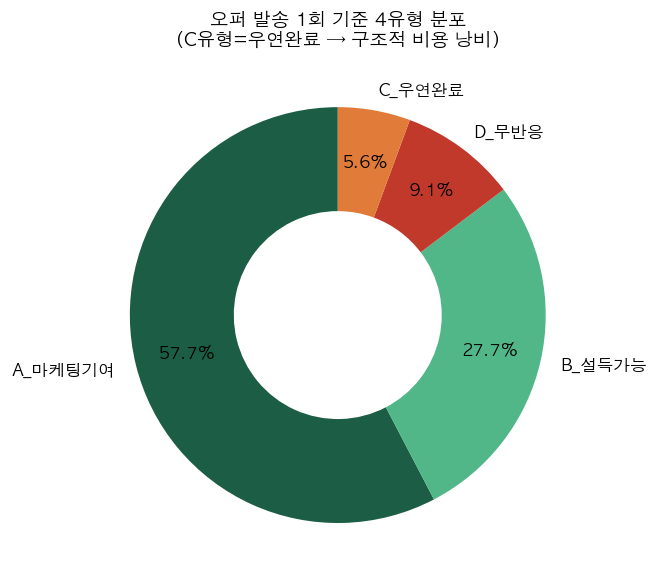

In [27]:
# A: View O + Complete O  → 마케팅 기여
# B: View O + Complete X  → 설득 가능
# C: View X + Complete O  → 우연완료 (마케팅 비기여)
# D: View X + Complete X  → 무반응

df_recv2 = df_master[df_master['event']=='offer received'][['person','offer_id_parsed','time']].copy()
df_view2 = df_master[df_master['event']=='offer viewed'][['person','offer_id_parsed']].copy()
df_comp2 = df_master[df_master['event']=='offer completed'][['person','offer_id_parsed']].copy()
df_view2['viewed']=True; df_comp2['completed']=True

df_f2 = (df_recv2
         .merge(df_view2, on=['person','offer_id_parsed'], how='left')
         .merge(df_comp2, on=['person','offer_id_parsed'], how='left'))
df_f2['viewed']    = df_f2['viewed'].fillna(False)
df_f2['completed'] = df_f2['completed'].fillna(False)

def classify(row):
    v,c = row['viewed'], row['completed']
    if   v and c:     return 'A_마케팅기여'
    elif v and not c: return 'B_설득가능'
    elif not v and c: return 'C_우연완료'
    else:             return 'D_무반응'

df_f2['type4'] = df_f2.apply(classify, axis=1)
type_counts    = df_f2['type4'].value_counts()
total_f2       = len(df_f2)

print("[오퍼 발송 1회 기준 4유형 분류]")
for t,cnt in type_counts.items():
    print(f"  {t:<15}: {cnt:>7,}건  ({cnt/total_f2:.1%})")

c_count = type_counts.get('C_우연완료',0)
print(f"\n▶ 우연완료(C유형) 비중: {c_count/total_f2:.1%}")

# 도넛 차트
fig, ax = plt.subplots(figsize=(7,5))
labels_pie = type_counts.index.tolist()
sizes_pie  = type_counts.values.tolist()
colors_pie = [C_GREEN,C_TEAL,C_RED,C_ORANGE][:len(labels_pie)]
wedges, texts, autotexts = ax.pie(
    sizes_pie, labels=labels_pie, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    wedgeprops=dict(width=0.5), pctdistance=0.75)
ax.set_title('오퍼 발송 1회 기준 4유형 분포\n(C유형=우연완료 → 구조적 비용 낭비)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

### 7-3. 구조적 비용 낭비 비중

In [28]:
df_c = df_f2[df_f2['type4']=='C_우연완료'].copy()
df_c = df_c.merge(
    df_portfolio[['id','offer_type','reward']].rename(columns={'id':'offer_id_parsed'}),
    on='offer_id_parsed', how='left')

total_completed   = df_f2['completed'].sum()
c_completed       = len(df_c)
total_reward_cost = df_master[df_master['event']=='offer completed']['reward'].sum()
c_reward_cost     = df_c['reward'].sum()
total_recv        = total_f2
c_recv            = len(df_c)

print("=" * 60)
print(f"{'구분':<18}{'전체':>10}{'C유형':>10}{'비중':>8}")
print("-" * 60)
print(f"{'구매 완료 건수':<18}{total_completed:>10,}{c_completed:>10,}{c_completed/total_completed:>8.1%}")
print(f"{'리워드 비용':<18}{total_reward_cost:>10,.0f}{c_reward_cost:>10,.0f}{c_reward_cost/total_reward_cost:>8.1%}")
print(f"{'오퍼 발송 수':<18}{total_recv:>10,}{c_recv:>10,}{c_recv/total_recv:>8.1%}")
print("=" * 60)
print(f"\nC타입 낭비 리워드: ${c_reward_cost:,.0f}")
print(f"비기여 비용 비중 : {c_reward_cost/total_reward_cost:.1%}")
print(f"글로벌 확산 시   : $100K+ 절감 기대")

구분                        전체       C유형      비중
------------------------------------------------------------
구매 완료 건수              64,992     5,784    8.9%
리워드 비용               160,541    26,463   16.5%
오퍼 발송 수              102,693     5,784    5.6%

C타입 낭비 리워드: $26,463
비기여 비용 비중 : 16.5%
글로벌 확산 시   : $100K+ 절감 기대


### 7-4. 우연완료 vs 일반 고객 비교

[우연완료 vs 일반 고객 비교]


,우연완료,일반(A유형)
평균 방문일수,9.25,9.27
평균 방문간격,3.57,3.55
평균 결제금액,13.95,13.33
리워드/매출 %,15.38,14.21


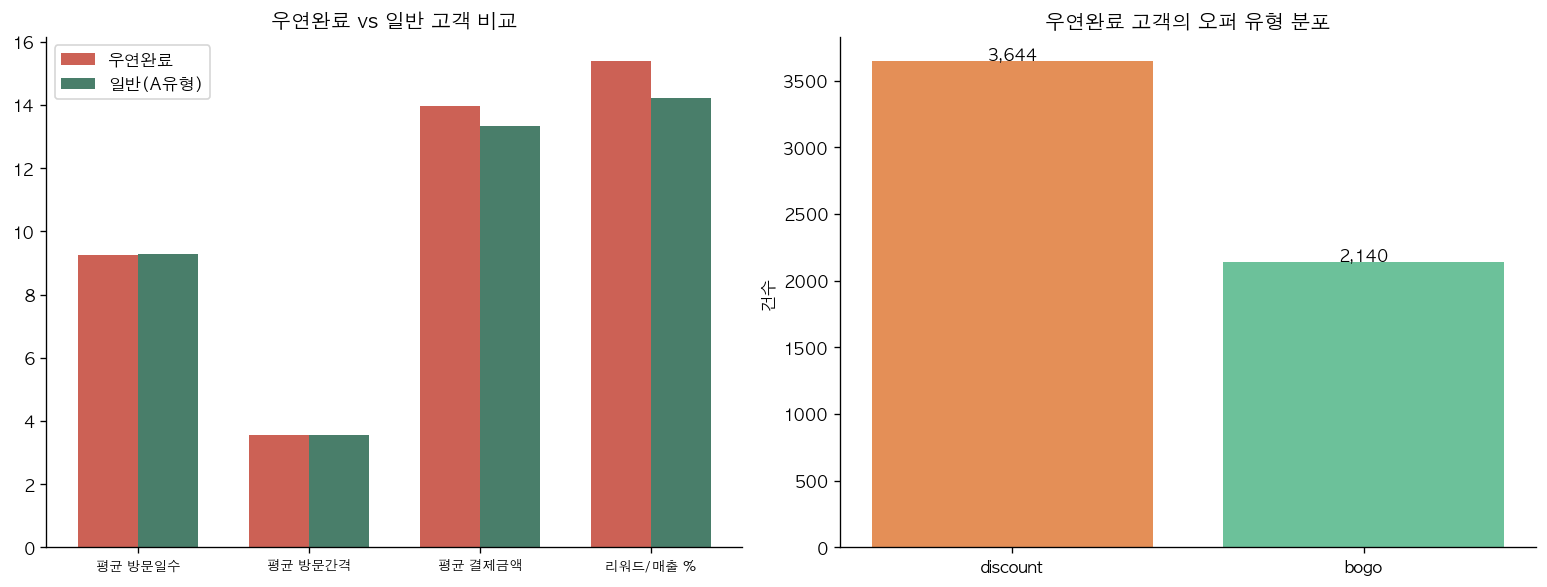

In [29]:
accidental_ids = set(df_c['person'])
normal_ids     = set(df_f2[df_f2['type4']=='A_마케팅기여']['person'])

def get_stats(ids, label):
    sub_tx  = df_master[(df_master['event']=='transaction') & (df_master['person'].isin(ids))]
    sub_cs  = customer_stats[customer_stats['person'].isin(ids)]
    return pd.Series({
        '평균 방문일수':  sub_tx.groupby('person')['time'].nunique().mean(),
        '평균 방문간격':  sub_cs['avg_gap_days'].mean(),
        '평균 결제금액':  sub_tx['amount'].mean(),
        '리워드/매출 %':  sub_cs['reward_ratio'].mean()*100,
    }, name=label)

comp_df = pd.concat([get_stats(accidental_ids,'우연완료'), get_stats(normal_ids,'일반(A유형)')], axis=1).round(2)
print("[우연완료 vs 일반 고객 비교]"); display(comp_df)

# 시각화
fig, axes = plt.subplots(1,2,figsize=(13,5))
ax = axes[0]
x = np.arange(len(comp_df)); w = 0.35
ax.bar(x-w/2, comp_df['우연완료'],  w, label='우연완료', color=C_RED,   alpha=0.8)
ax.bar(x+w/2, comp_df['일반(A유형)'],w, label='일반(A유형)', color=C_GREEN,alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(comp_df.index, fontsize=8)
ax.set_title('우연완료 vs 일반 고객 비교'); ax.legend()

ax = axes[1]
c_otype = df_c['offer_type'].value_counts()
ax.bar(c_otype.index, c_otype.values, color=[C_ORANGE,C_TEAL,C_GOLD][:len(c_otype)], alpha=0.85)
for i,(idx,val) in enumerate(c_otype.items()):
    ax.text(i, val+10, f'{val:,}', ha='center', fontsize=10)
ax.set_title('우연완료 고객의 오퍼 유형 분포'); ax.set_ylabel('건수')

plt.tight_layout(); plt.show()

### 7-5. Net Lift Index & Cannibalization Rate → 2×2 전략 매트릭스

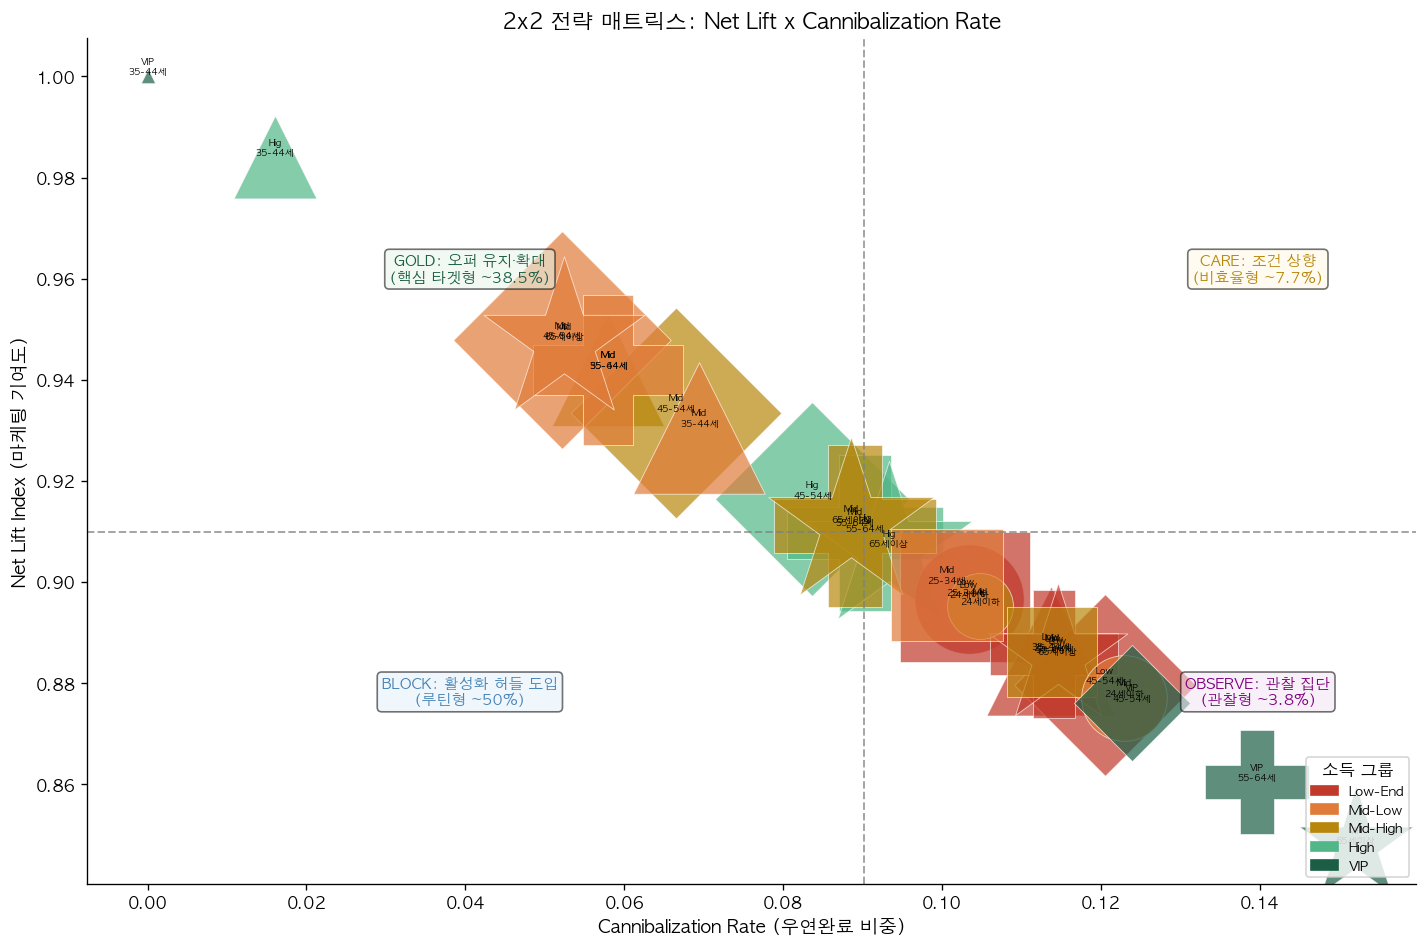

In [31]:
df_f2_seg = df_f2.merge(
    df_master[['person','income_group','age_group','gender_clean']].drop_duplicates('person'),
    on='person', how='left')

seg_metrics = (df_f2_seg.groupby(['income_group','age_group'])
               .apply(lambda g: pd.Series({
                   'A': (g['type4']=='A_마케팅기여').sum(),
                   'C': (g['type4']=='C_우연완료').sum(),
                   'n': len(g)}))
               .reset_index())

seg_metrics['net_lift']  = seg_metrics['A'] / (seg_metrics['A']+seg_metrics['C']+1e-9)
seg_metrics['cann_rate'] = seg_metrics['C'] / (seg_metrics['A']+seg_metrics['C']+1e-9)

avg_nli  = seg_metrics['net_lift'].mean()
avg_cann = seg_metrics['cann_rate'].mean()

inc_order  = ['Low-End','Mid-Low','Mid-High','High','VIP']
color_inc2 = dict(zip(inc_order,[C_RED,C_ORANGE,C_GOLD,C_TEAL,C_GREEN]))
age_marker = {'24세이하':'o','25-34세':'s','35-44세':'^','45-54세':'D','55-64세':'P','65세이상':'*'}

fig, ax = plt.subplots(figsize=(12,8))
for _, row in seg_metrics.dropna().iterrows():
    c = color_inc2.get(row['income_group'],'#999')
    m = age_marker.get(row['age_group'],'o')
    ax.scatter(row['cann_rate'], row['net_lift'],
               s=max(row['n']*1.5,30), marker=m, color=c, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.annotate(f"{row['income_group'][:3]}\n{row['age_group']}",
                (row['cann_rate'], row['net_lift']), fontsize=5.5, ha='center', va='bottom')

ax.axvline(avg_cann, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(avg_nli,  color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

bbox_kw = lambda fc: dict(boxstyle='round,pad=0.3', facecolor=fc, alpha=0.55)
y_top  = seg_metrics['net_lift'].max()
y_bot  = seg_metrics['net_lift'].min()
x_avg  = avg_cann

ax.text(x_avg*0.45, avg_nli+(y_top-avg_nli)*0.55,
        'GOLD: 오퍼 유지·확대\n(핵심 타겟형 ~38.5%)',
        fontsize=9, fontweight='bold', color=C_GREEN, ha='center',
        bbox=bbox_kw('#E8F5E9'))
ax.text(x_avg*1.55, avg_nli+(y_top-avg_nli)*0.55,
        'CARE: 조건 상향\n(비효율형 ~7.7%)',
        fontsize=9, fontweight='bold', color=C_GOLD, ha='center',
        bbox=bbox_kw('#FFF9E6'))
ax.text(x_avg*0.45, avg_nli-(avg_nli-y_bot)*0.55,
        'BLOCK: 활성화 허들 도입\n(루틴형 ~50%)',
        fontsize=9, fontweight='bold', color='steelblue', ha='center',
        bbox=bbox_kw('#E3F2FD'))
ax.text(x_avg*1.55, avg_nli-(avg_nli-y_bot)*0.55,
        'OBSERVE: 관찰 집단\n(관찰형 ~3.8%)',
        fontsize=9, fontweight='bold', color='purple', ha='center',
        bbox=bbox_kw('#F3E5F5'))

patches = [mpatches.Patch(color=v, label=k) for k,v in color_inc2.items()]
ax.legend(handles=patches, title='소득 그룹', loc='lower right', fontsize=8)
ax.set_xlabel('Cannibalization Rate (우연완료 비중)', fontsize=11)
ax.set_ylabel('Net Lift Index (마케팅 기여도)', fontsize=11)
ax.set_title('2x2 전략 매트릭스: Net Lift x Cannibalization Rate',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 7-6. 최종 결론 — 솔루션 제안 & 비용 요약

In [32]:
print("=" * 65)
print("  Phase 3 최종 결과 요약")
print("=" * 65)
print(f"  C타입 리워드 (우연완료 지급 비용) : ${c_reward_cost:>10,.0f}")
print(f"  전체 리워드 대비 비기여 비중      : {c_reward_cost/total_reward_cost:>10.1%}")
print(f"  글로벌 확산 시 절감 기대          :     $100,000+")
print("=" * 65)

print()
print("  솔루션: UI 변경 — '오퍼 활성화 버튼' 도입")
print("  ─────────────────────────────────────────────────────────")
print("  Step 1. 앱에 '오퍼 활성화' 버튼 추가")
print("  Step 2. 고객이 스스로 오퍼를 활성화")
print("  Step 3. 직접 활성화한 경우에만 리워드 적립")
print()
print("  기대 효과")
print("  - 우연완료 고객에게 지급되는 불필요한 리워드 ~70% 감소")
print("  - 타겟팅 정확도 향상 -> 마케팅 효율성 개선")
print()
print("─" * 65)
print()
print("  최종 결론")
print()
print("    문제 != 개인화의 정교함")
print("    '비용이 누수되는 구조를 그대로 운영하는 것'")
print()
print("    고객을 더 쪼개기보다 비용의 구멍부터 막고,")
print("    '진짜로 반응하는 고객에게만 예산을 집중'")
print("─" * 65)

  Phase 3 최종 결과 요약
  C타입 리워드 (우연완료 지급 비용) : $    26,463
  전체 리워드 대비 비기여 비중      :      16.5%
  글로벌 확산 시 절감 기대          :     $100,000+

  솔루션: UI 변경 — '오퍼 활성화 버튼' 도입
  ─────────────────────────────────────────────────────────
  Step 1. 앱에 '오퍼 활성화' 버튼 추가
  Step 2. 고객이 스스로 오퍼를 활성화
  Step 3. 직접 활성화한 경우에만 리워드 적립

  기대 효과
  - 우연완료 고객에게 지급되는 불필요한 리워드 ~70% 감소
  - 타겟팅 정확도 향상 -> 마케팅 효율성 개선

─────────────────────────────────────────────────────────────────

  최종 결론

    문제 != 개인화의 정교함
    '비용이 누수되는 구조를 그대로 운영하는 것'

    고객을 더 쪼개기보다 비용의 구멍부터 막고,
    '진짜로 반응하는 고객에게만 예산을 집중'
─────────────────────────────────────────────────────────────────
